# 1. LoRA - BERT 모델을 사용한 PEFT
BERT 모델을 사용하여 PEFT(LoRA) 사용

In [ ]:
# =============================================================================
# [오늘 실습의 핵심: BERT + LoRA를 이용한 효율적 미세조정(PEFT)]
# =============================================================================
#
# 1. 오늘 배우는 것의 정체 (What):
#    - 구글이 만든 천재적인 언어 모델 'BERT'를 가져옵니다.
#    - 이 녀석에게 문장을 주면 '기쁨, 슬픔, 분노...' 등 6가지 감정 중 하나를 맞추게 시킬 겁니다.
#    - 핵심 기술: **LoRA (Low-Rank Adaptation)**
#      -> BERT의 수억 개 파라미터를 전부 다시 학습시키면(Full Fine-tuning) GPU 메모리가 터지거나 시간이 오래 걸립니다.
#      -> 대신, BERT는 꽁꽁 얼려두고(Freeze), 옆에 아주 작은 '보조 회로(Adapter)'만 붙여서 그것만 학습시킵니다.
#      -> 결과: 학습 속도는 빠르고 메모리는 적게 쓰면서, 성능은 전체 학습과 비슷하게 나옵니다.
#
# 2. 전체 흐름 (Flow):
#    ① 환경 설정: 필요한 도구(라이브러리) 설치 및 로그인.
#    ② 모델 로드: 뼈대가 될 BERT 모델을 불러옵니다. (오늘 분석할 부분)
#    ③ 데이터 로드: 감정 데이터(Emotion Dataset)를 가져옵니다.
#    ④ 전처리: 문장을 기계가 이해하는 숫자(Token)로 바꿉니다.
#    ⑤ LoRA 설정: BERT 모델에 'LoRA 어댑터'라는 보조 장치를 장착합니다. (가장 중요!)
#    ⑥ 학습(Training): 보조 장치만 집중적으로 학습시킵니다.
#    ⑦ 평가 및 저장: 잘 맞추는지 확인하고, 가벼운 어댑터 파일만 저장합니다.
#
# 3. 왜 이걸 하는가? (Why):
#    - 현업에서 거대 모델(LLM)을 내 서비스에 맞게 튜닝하고 싶은데,
#      GPU 자원은 한정적일 때 사용하는 가장 표준적인 방법입니다.
#
# =============================================================================

# -----------------------------------------------------------------------------
# 1. 필수 라이브러리 설치
# -----------------------------------------------------------------------------
# transformers: Hugging Face의 핵심. 모델(BERT)과 토크나이저를 쓰기 위해 필요.
# trl: 강화학습 관련 라이브러리지만, 여기선 학습 편의성을 위해 설치.
# datasets: 학습에 쓸 데이터(예: Emotion 데이터셋)를 쉽게 다운로드하는 도구.
# evaluate: 모델이 얼마나 똑똑해졌는지 점수(정확도 등)를 매기는 도구.
# peft: **오늘의 주인공**. 모델을 가볍게 튜닝(LoRA)할 수 있게 해주는 라이브러리.
# ! (느낌표)는 파이썬 코드가 아니라 리눅스 터미널 명령어라는 뜻입니다.
# -----------------------------------------------------------------------------
!pip install "transformers" "trl" "datasets" "evaluate" "matplotlib-venn"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.4 MB/s eta 0:00:00


## 허깅페이스 계정에 로그인

In [ ]:
# -----------------------------------------------------------------------------
# 2. Hugging Face 로그인
# -----------------------------------------------------------------------------
# 허깅페이스 허브에 있는 모델이나 데이터를 가져오기 위해 인증하는 과정입니다.
# 공개된 모델(BERT base)은 로그인이 없어도 되지만, Llama 같은 최신 모델은 필수입니다.
# 실행하면 토큰을 입력하는 창이 뜹니다. (설정에서 Access Token 발급 필요)
# -----------------------------------------------------------------------------
from huggingface_hub import notebook_login
notebook_login()

## BERT 모델 로드

In [ ]:
# -----------------------------------------------------------------------------
# 3. 모델 로드 및 구조 확인 (여기가 제일 중요합니다)
# -----------------------------------------------------------------------------

# 필요한 도구들을 서랍(라이브러리)에서 꺼냅니다.
from transformers import (
    AutoTokenizer,                     # 문장을 숫자로 쪼개주는 칼 (토크나이저)
    AutoModelForSequenceClassification, # 문장을 읽고 분류(Classification)를 하는 모델 설계도
    Trainer,                           # 학습을 대신 시켜주는 조교 선생님
    TrainingArguments                  # 조교 선생님께 전달할 학습 지침서 (몇 번 공부할지 등)
)

# [BERT 모델 불러오기]
# AutoModelForSequenceClassification.from_pretrained(...)
# -> "BERT야, 너 원래 똑똑한 거 아는데, 이번엔 '문장 분류' 업무를 좀 해줘야겠다."라고 부르는 겁니다.
#
# "bert-base-uncased":
# -> BERT 모델 중에서도 'Base(기본 크기)' 모델을 가져옵니다.
# -> 'uncased'는 대소문자 구분을 안 한다는 뜻입니다 (Love == love).
#
# num_labels=6:
# -> 이게 핵심입니다. BERT의 머리 끝부분에 '출구 6개짜리 문'을 새로 달아줍니다.
# -> 왜냐하면 우리가 쓸 데이터(Emotion)의 정답이 6개(기쁨, 슬픔, 분노, 두려움, 사랑, 놀람)니까요.
base_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=6
)

# -----------------------------------------------------------------------------
# [실행 결과 경고문 해석]
# "Some weights of BertForSequenceClassification were not initialized..."
# -> 이 빨간 글씨는 에러가 아니라 **정상적인 경고**입니다. 쫄지 마세요.
# -> 뜻: "BERT 몸통은 학습된 걸 가져왔는데, 네가 방금 달아달라고 한 '6개짜리 분류기(classifier)'는
#         아직 학습 안 된 쌩판 새거(랜덤 값)야. 그러니까 꼭 학습(Fine-tuning) 시켜서 써라!"
# -> 우리는 지금부터 학습을 시킬 거니까 계획대로 되고 있는 겁니다.
# -----------------------------------------------------------------------------

# -----------------------------------------------------------------------------
# 4. 모델 구조 뜯어보기 (base_model 변수 출력)
# -----------------------------------------------------------------------------
# 출력된 내용을 보면 모델이 어떻게 생겼는지 나옵니다.
#
# BertForSequenceClassification(
#   (bert): BertModel(...)       -> 여기가 [몸통]입니다. 이미 엄청 똑똑한 녀석이죠. (Embeddings, Encoder 등)
#                                   우리는 나중에 이 몸통을 얼려버릴(Freeze) 겁니다.
#
#   (classifier): Linear(...)    -> 여기가 [머리]입니다.
#      (in_features=768, out_features=6)
#      -> 몸통에서 나온 768개의 정보를 받아서, 최종적으로 6개의 감정 중 하나로 찍는 역할을 합니다.
#      -> 이 부분이 위에서 말한 '새로 달린 멍청한 부분'이라 학습이 필요합니다.
# )
# -----------------------------------------------------------------------------
base_model

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

## 데이터세트 로드

In [ ]:
# =============================================================================
# [Step 2: 데이터셋 준비 - 공부할 교과서 가져오기]
# =============================================================================
#
# 1. 개념 (Concept):
#    - 텅 빈 BERT 모델에게 "이 문장은 슬픈 거야, 저건 기쁜 거야"라고 가르치려면 정답지가 필요합니다.
#    - 우리는 'dair-ai/emotion'이라는 유명한 데이터셋을 씁니다. (트위터 데이터 기반)
#    - 데이터는 보통 3덩어리로 쪼개서 씁니다:
#      ① Train(훈련용): 모델이 공부할 때 쓰는 문제집 (16,000개)
#      ② Validation(검증용): 모의고사 (공부 중간중간 실력 확인용, 2,000개)
#      ③ Test(테스트용): 수능 (최종 성능 평가용, 2,000개)
#
# 2. 실행 결과 해석 (Output Interpretation):
#    - 다운로드 로그를 보니 16,000개의 훈련 데이터(Train split)가 잘 받아졌습니다.
#    - dataset['train'][0] 출력 결과: {'text': 'i didnt feel humiliated', 'label': 0}
#      -> 문장(text): "나 굴욕감을 느끼지 않았어"
#      -> 정답(label): 0
#      -> **중요**: 컴퓨터는 '슬픔'이란 글자를 모르니 숫자로 바꿉니다. 여기서 0은 '슬픔(Sadness)'입니다.
#
#    [참고: 라벨 번호표]
#    0: sadness (슬픔)
#    1: joy (기쁨)
#    2: love (사랑)
#    3: anger (분노)
#    4: fear (두려움)
#    5: surprise (놀람)
# =============================================================================

from datasets import load_dataset

# -----------------------------------------------------------------------------
# 1. 데이터 다운로드
# -----------------------------------------------------------------------------
# load_dataset 함수:
# -> 허깅페이스 허브(클라우드)에서 "dair-ai/emotion"이라는 이름의 데이터를 찾아 내 컴퓨터로 복사해옵니다.
# -> 다운로드가 완료되면 자동으로 Train/Validation/Test로 나누어 줍니다.
dataset = load_dataset("dair-ai/emotion")

# -----------------------------------------------------------------------------
# 2. 데이터 확인 (첫 번째 데이터 찍어보기)
# -----------------------------------------------------------------------------
# dataset['train']: 훈련용 데이터 뭉치를 선택합니다.
# [0]: 그 중에서 가장 첫 번째 데이터 하나를 꺼냅니다.
#
# 이걸 찍어보는 이유:
# -> 데이터가 잘 받아졌는지, 그리고 데이터 구조(key값)가 'text'와 'label'로 되어 있는지 확인하기 위함입니다.
# -> 나중에 모델에 넣을 때 이 key 이름('text')을 정확히 알아야 하기 때문입니다.
dataset['train'][0]

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'text': 'i didnt feel humiliated', 'label': 0}

## 토크나이저 설정

In [ ]:
# =============================================================================
# [Step 3: 토크나이징 (Tokenization) - 기계가 이해하는 숫자로 번역]
# =============================================================================
#
# 1. 개념 (Concept):
#    - 컴퓨터는 "Happy"라는 글자를 이해하지 못합니다. 숫자로 줘야 계산을 합니다.
#    - 토크나이저(Tokenizer)는 '사전(Vocabulary)'을 가지고 있어서, 글자를 숫자로 바꿔줍니다.
#    - (예: "I love you" -> [1045, 2293, 2017])
#
# 2. 왜 길이를 맞추는가? (Padding & Truncation):
#    - 모델은 한 번에 여러 문장(배치)을 처리하는데, 이때 모든 문장의 길이가 똑같아야 행렬 계산이 가능합니다.
#    - 마치 엑셀 표를 만들 때 칸을 맞추는 것과 같습니다.
#    - 짧은 문장은 뒤에 '0'을 채워서 길이를 늘리고(Padding),
#    - 너무 긴 문장은 잘라버려서(Truncation) 모든 문장을 '128개' 숫자 길이로 통일합니다.
#
# 3. 결과물 해석 (Output Analysis):
#    - 실행 결과 나온 'train_ds[0]'을 보면 두 가지 핵심 데이터가 보입니다.
#      ① input_ids: 실제 문장이 숫자로 바뀐 것.
#         -> [101, 1045, ... 102, 0, 0, 0 ...]
#         -> 101 ([CLS]): 문장의 시작을 알리는 신호탄.
#         -> 102 ([SEP]): 문장의 끝을 알리는 신호탄.
#         -> 0 (PAD): 빈 공간을 채우기 위한 의미 없는 숫자.
#      ② attention_mask: 모델에게 "어디를 봐야 하는지" 알려주는 지도.
#         -> [1, 1, ... 1, 0, 0 ...]
#         -> 1: "이건 진짜 단어니까 집중해서 봐!"
#         -> 0: "이건 그냥 빈칸 채운 거니까 무시해!"
# =============================================================================

# -----------------------------------------------------------------------------
# 1. 토크나이저 로드
# -----------------------------------------------------------------------------
# AutoTokenizer.from_pretrained(...)
# -> 아까 불러온 BERT 모델('bert-base-uncased')과 **똑같은 짝꿍** 토크나이저를 가져옵니다.
# -> 중요: 모델은 BERT인데 토크나이저를 GPT 것을 쓰면 서로 말이 안 통합니다. (영어 모델에 한글 입력하는 꼴)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# -----------------------------------------------------------------------------
# 2. 전처리 함수 정의 (번역 규칙 만들기)
# -----------------------------------------------------------------------------
def preprocess(example):
    # tokenizer(...): 문장을 넣으면 숫자로 변환해주는 마법의 함수
    return tokenizer(
        example["text"],       # 변환할 실제 문장 ("i didnt feel humiliated")
        truncation=True,       # 문장이 128보다 길면? -> 뒤를 잘라버려라 (오류 방지)
        padding="max_length",  # 문장이 128보다 짧으면? -> 나머지를 0으로 채워라 (길이 통일)
        max_length=128         # 문장의 최대 길이를 128개 토큰으로 고정
    )

# -----------------------------------------------------------------------------
# 3. 전체 데이터 변환 (맵핑)
# -----------------------------------------------------------------------------
# dataset.map(...): 데이터셋의 모든 문장에 위에서 만든 preprocess 함수를 한 번에 적용합니다.
# batched=True: 한 문장씩 하지 않고 뭉텅이로 처리해서 속도가 훨씬 빠릅니다.
tokenized = dataset.map(preprocess, batched=True)

# -----------------------------------------------------------------------------
# 4. 컬럼 이름 변경 (중요!)
# -----------------------------------------------------------------------------
# rename_column("label", "labels"):
# -> 원래 데이터셋의 정답 컬럼 이름은 'label'입니다.
# -> 그런데 Hugging Face의 Trainer는 정답을 찾을 때 무조건 **'labels'** (복수형)라는 이름을 찾습니다.
# -> 이름을 안 바꿔주면 "정답이 없는데요?" 하고 에러가 납니다. 꼭 바꿔줘야 합니다.
tokenized = tokenized.rename_column("label", "labels")

# -----------------------------------------------------------------------------
# 5. 형식 설정 (PyTorch용)
# -----------------------------------------------------------------------------
# set_format(type="torch", ...):
# -> 이제부터 데이터는 일반 리스트가 아니라 '파이토치 텐서(Tensor)'로 다루겠다고 선언합니다.
# -> GPU에 올려서 계산하려면 텐서 형식이어야 합니다.
# -> 필요한 컬럼인 input_ids(숫자문장), attention_mask(집중지도), labels(정답)만 남깁니다.
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# 훈련용과 검증용 데이터를 변수에 따로 담아둡니다.
train_ds = tokenized["train"]
eval_ds  = tokenized["validation"]

# -----------------------------------------------------------------------------
# 6. 변환 결과 확인 (첫 번째 데이터)
# -----------------------------------------------------------------------------
# 출력된 결과를 보세요:
# input_ids: 101(시작)로 시작해서 중간에 숫자들(단어)이 있고, 102(끝) 뒤로는 전부 0입니다.
# attention_mask: 단어가 있는 곳은 1, 0인 곳(패딩)은 0으로 되어 있습니다.
# labels: tensor(0) -> 정답은 0번(sadness)입니다.
train_ds[0]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'labels': tensor(0),
 'input_ids': tensor([  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,  

##  PEFT - Lora 설정과 학습

In [ ]:
# =============================================================================
# [Step 4: LoRA 설정 및 본격적인 학습 (Training)]
# =============================================================================
#
# 1. 개념 (Concept):
#    - BERT는 파라미터가 1억 개가 넘습니다. 이걸 다 학습(Full Fine-tuning)하려면 시간이 오래 걸립니다.
#    - LoRA는 기존 모델(BERT)은 건드리지 않고(Freeze), 옆에 아주 작은 '바이패스 회로(Rank Decomposition Matrices)'를 붙입니다.
#    - 우리는 이 작은 회로만 학습시킵니다.
#    - 결과: 학습 파라미터 수가 획기적으로 줄어듭니다 (보통 전체의 1% 미만).
#
# 2. 코드 설명 (Line by Line):
# =============================================================================

from peft import LoraConfig, get_peft_model
import evaluate

# -----------------------------------------------------------------------------
# 1. LoRA 설계도 작성 (Config)
# -----------------------------------------------------------------------------
lora_config = LoraConfig(
    task_type="SEQ_CLS",  # Sequence Classification: 우리가 하는 게 '문장 분류'니까요.
    r=8,                  # Rank(랭크): LoRA의 핵심.
                          # -> 이 숫자가 클수록 학습할 파라미터가 많아져 똑똑해지지만 느려집니다.
                          # -> 8 정도면 가성비가 아주 훌륭한 수준입니다.
    lora_alpha=32,        # 스케일링 계수: 학습된 LoRA 가중치를 기존 모델에 얼마나 강하게 반영할지 결정.
    lora_dropout=0.05,    # 과적합(Overfitting) 방지를 위해 5%의 뉴런을 랜덤하게 끕니다.
    target_modules=["query", "key", "value", "output.dense"],
                          # -> BERT 내부의 'Attention' 부품 중 어디에 LoRA를 붙일지 정합니다.
                          # -> 보통 query, key, value에 붙이면 효과가 좋습니다.
)

# -----------------------------------------------------------------------------
# 2. 모델에 LoRA 장착
# -----------------------------------------------------------------------------
# get_peft_model:
# -> 아까 불러온 뚱뚱한 base_model에 가벼운 lora_config를 씌웁니다.
# -> 이제 이 모델은 학습시킬 때 몸통은 안 변하고, LoRA 부분만 변하게 됩니다.
model = get_peft_model(base_model, lora_config)

# -----------------------------------------------------------------------------
# 3. 학습 규칙 설정 (TrainingArguments)
# -----------------------------------------------------------------------------
training_args = TrainingArguments(
    output_dir="./lora_bert_mrpc", # 학습 중간중간 저장할 폴더 위치
    num_train_epochs=3,            # 교과서(데이터셋)를 처음부터 끝까지 3번 봅니다.
    per_device_train_batch_size=16,# 한 번에 16문제씩 풀고 정답 맞추기.
    per_device_eval_batch_size=16, # 채점할 때도 16문제씩.
    eval_strategy="steps",         # "Epoch마다 말고, 스텝(step)마다 평가해줘"
    logging_steps=20,              # 20번 학습할 때마다 로그(기록)를 보여줘.
    save_steps=200,                # 200번 학습할 때마다 모델 저장해줘.
    learning_rate=2e-5,            # 학습률: 보폭. 너무 크면 건너뛰고, 너무 작으면 안 배움.
    load_best_model_at_end=True,   # 학습 다 끝나면, 가장 성적 좋았던 때의 모델을 불러와.
    metric_for_best_model="accuracy", # "성적의 기준은 '정확도'야."
    push_to_hub=False,             # 인터넷(허브)에 올리진 않겠다.
    report_to="none",              # 완드비(WandB) 같은 외부 리포팅 툴 끄기.
)

# -----------------------------------------------------------------------------
# 4. 채점 기준 만들기 (Metric)
# -----------------------------------------------------------------------------
metric = evaluate.load('accuracy') # 정확도 채점기 로드

def compute_metrics(eval_pred):
    logits, labels = eval_pred     # 모델의 예측값(logits)과 정답(labels)을 받음
    preds = logits.argmax(axis=-1) # logits는 확률 점수(소수점)로 나오니, 제일 높은 점수의 번호를 뽑음
    return metric.compute(predictions=preds, references=labels) # 정답과 비교해서 점수 리턴

# -----------------------------------------------------------------------------
# 5. 조교 선생님(Trainer) 고용 및 학습 시작
# -----------------------------------------------------------------------------
trainer = Trainer(
    model=model,                  # LoRA 장착된 모델
    args=training_args,           # 학습 규칙
    train_dataset=train_ds,       # 공부할 문제집
    eval_dataset=eval_ds,         # 모의고사 문제집
    tokenizer=tokenizer,          # 번역기 (데이터 처리용)
    compute_metrics=compute_metrics # 채점 기준
)

# 학습 시작! (이 명령어가 실행되는 동안 로그가 촤라락 뜹니다)
trainer.train()

# =============================================================================
# [학습 로그 해석 (Output Analysis)]
# =============================================================================
# 출력된 표를 보세요.
#
# Step 20:
#   - Loss: 1.80... (오차가 큼)
#   - Accuracy: 0.28 (28점. 6개 중에 하나 찍으면 16점이니까 거의 찍는 수준)
#
# ... (학습 진행 중) ...
#
# Step 3000 (마지막):
#   - Validation Loss: 0.86 (오차가 많이 줄었음)
#   - Accuracy: 0.706 (70.6점!)
#
# 결론:
# 모델이 감정을 읽는 법을 배웠습니다!
# 100점은 아니지만, 아주 적은 리소스(LoRA)로 짧게 학습한 것치고는 훌륭한 결과입니다.
# =============================================================================

/tmp/ipython-input-1542683702.py:40: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss,Validation Loss,Accuracy
20,1.800500,1.757964,0.284500
40,1.737400,1.704329,0.351500
60,1.703100,1.664235,0.352500
80,1.659000,1.637356,0.352500
100,1.659100,1.616975,0.352500
120,1.629400,1.603476,0.352500
140,1.619500,1.594790,0.352000
160,1.611600,1.588681,0.352000
180,1.597700,1.583135,0.352000
200,1.570300,1.577623,0.352000


TrainOutput(global_step=3000, training_loss=1.1338222920099894, metrics={'train_runtime': 1522.4465, 'train_samples_per_second': 31.528, 'train_steps_per_second': 1.971, 'total_flos': 3192948965376000.0, 'train_loss': 1.1338222920099894, 'epoch': 3.0})

## 성능 평가 (Evaluate)

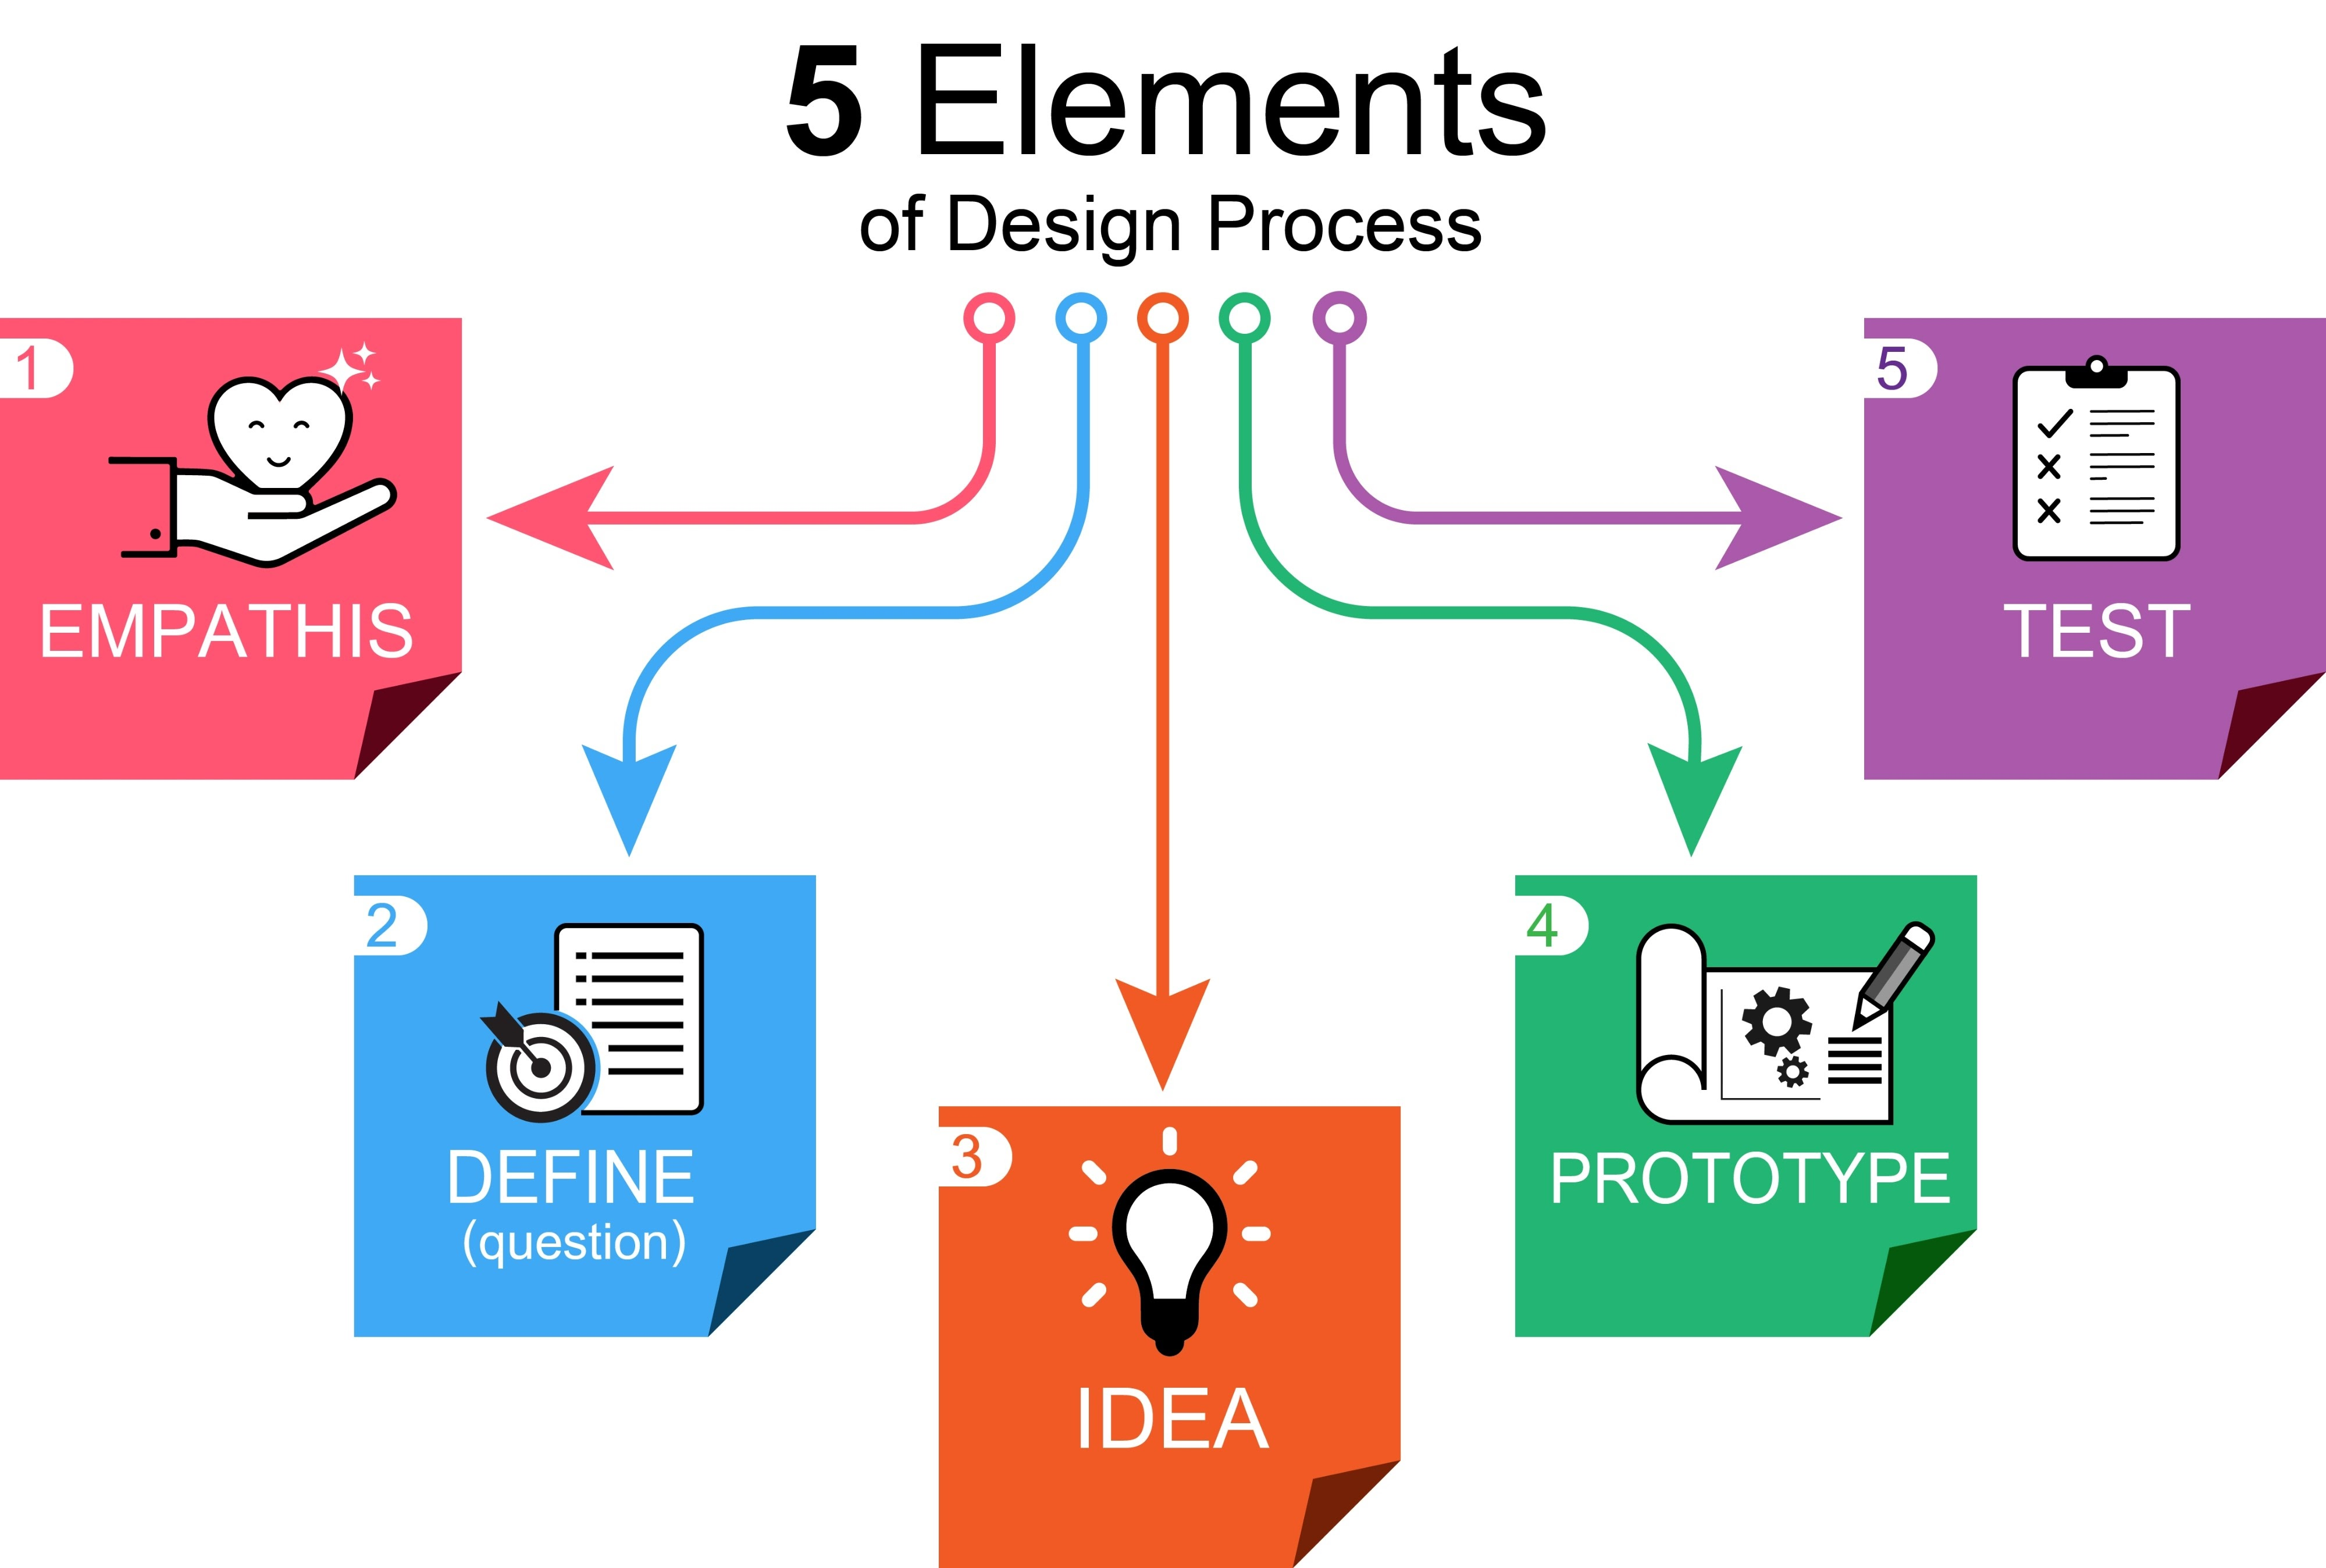

In [ ]:
# =============================================================================
# [Step 5, 6, 7: 평가, 저장, 그리고 실전 테스트 (Inference)]
# =============================================================================
#
# 1. 개념 (Concept):
#    ① 평가 (Evaluate): 모의고사(Validation Set)를 통해 최종 점수를 확인합니다.
#       -> 아까 학습 중에 본 것과 같지만, 마지막으로 확실하게 체크하는 과정입니다.
#    ② 저장 (Save): **LoRA의 꽃**입니다.
#       -> 일반적인 모델 저장: 400MB짜리 BERT 전체를 저장함.
#       -> LoRA 저장: BERT는 저장 안 하고, 우리가 학습시킨 '어댑터' 파일(약 2~3MB)만 저장함.
#       -> 나중에 쓸 때는 "원본 BERT + 저장된 어댑터"를 합쳐서 씁니다. 용량 효율이 엄청납니다.
#    ③ 추론 (Inference): 실제 서비스 단계입니다.
#       -> "문장 입력" -> "토크나이저(숫자 변환)" -> "모델(계산)" -> "가장 높은 점수 찾기" -> "결과 출력"
#
# 2. 코드 설명 (Line by Line):
# =============================================================================

# -----------------------------------------------------------------------------
# 5. 최종 성능 평가
# -----------------------------------------------------------------------------
# trainer.evaluate():
# -> 학습이 끝난 모델에게 검증 데이터(eval_ds)를 풀게 시킵니다.
eval_results = trainer.evaluate()

# 결과 출력
# -> f-string을 써서 소수점 4자리까지 깔끔하게 보여줍니다.
# -> 출력된 0.6775는 정확도 67.75%라는 뜻입니다. (감정이 6개나 되니 찍으면 16%인데, 꽤 준수한 성적입니다)
print(f"최종 정확도(Accuracy): {eval_results['eval_accuracy']:.4f}")

최종 정확도(Accuracy): 0.6775


## 모델 저장 (Save)
LoRA는 모델 전체가 아니라 학습된 '어댑터(Adapter)' 부분만 저장하면 됩니다. 용량이 매우 작아서 효율적입니다.

In [ ]:
# -----------------------------------------------------------------------------
# 6. 모델 저장 (Save) - LoRA의 핵심 장점
# -----------------------------------------------------------------------------
save_dir = "./bert-emotion-lora" # 저장할 폴더 이름

# model.save_pretrained(save_dir):
# -> 주의: 여기서 저장되는 건 거대한 BERT 모델 전체가 아닙니다.
# -> 방금 학습한 **'LoRA 어댑터 가중치'** (config.json, adapter_model.bin)만 저장됩니다.
# -> 그래서 저장 속도가 엄청 빠르고 용량도 작습니다.
model.save_pretrained(save_dir)

# tokenizer.save_pretrained(save_dir):
# -> 모델만 있으면 안 되고, 번역기(토크나이저) 설정도 같이 저장해야 나중에 똑같이 번역할 수 있습니다.
tokenizer.save_pretrained(save_dir)

print(f"모델이 '{save_dir}' 폴더에 저장되었습니다.")

모델이 './bert-emotion-lora' 폴더에 저장되었습니다.


## 실제 테스트 (Inference)
저장된 모델이 새로운 문장을 보고 감정을 잘 맞추는지 직접 테스트해 봅니다.

In [ ]:
# -----------------------------------------------------------------------------
# 7. 실제 테스트 (Inference) - "내 모델이 진짜 되나?"
# -----------------------------------------------------------------------------
import torch # 텐서 계산을 위해 파이토치 불러오기

# ① 테스트할 문장 준비 (영어)
text = "I feel so happy and excited today!"

# ② 입력 변환 (Preprocessing)
# -> tokenizer(text, ...): 문장을 숫자로 바꿉니다.
# -> return_tensors="pt": 결과를 파이썬 리스트가 아니라 '파이토치 텐서(pt)'로 달라고 요청합니다.
# -> .to(model.device): 이게 중요합니다. 모델이 GPU에 가 있다면, 데이터도 GPU로 보내야 계산이 됩니다.
inputs = tokenizer(text, return_tensors="pt").to(model.device)

# ③ 예측 (Prediction)
# with torch.no_grad():
# -> "지금은 학습(공부)하는 게 아니라 시험 치는 거야."
# -> 역전파(Backpropagation)를 위한 계산(기울기 저장)을 끕니다. 메모리를 아끼고 속도가 빨라집니다.
with torch.no_grad():
    # model(**inputs): 데이터를 모델에 넣습니다. (**는 딕셔너리 압축 해제)
    # .logits: 모델의 최종 출력값입니다. 6개의 숫자가 나옵니다. (각 감정일 확률 점수)
    logits = model(**inputs).logits

    # argmax(): 6개의 숫자 중 '가장 큰 값'이 있는 위치(인덱스)를 찾습니다.
    # .item(): 텐서 껍데기를 벗기고 순수 파이썬 숫자(int)로 가져옵니다.
    predicted_class_id = logits.argmax().item()

# ④ 결과 해석 (Post-processing)
# 모델은 숫자(0, 1, 2...)로만 대답하니까, 사람이 알아듣게 글자로 바꿔줍니다.
# 학습할 때 데이터셋의 순서와 똑같이 리스트를 만듭니다.
labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# 최종 결과 출력
print(f"입력 문장: {text}")
# labels[predicted_class_id]: 아까 뽑은 숫자(예: 1)를 리스트에 넣어 'joy'를 가져옵니다.
print(f"예측 감정: {labels[predicted_class_id]}")

# =============================================================================
# [총평]
# 축하합니다! 오늘 실습으로 여러분은:
# 1. Hugging Face에서 남이 만든 뇌(BERT)를 가져와서,
# 2. 내 데이터(Emotion)에 맞게 효율적으로 가르치고(LoRA),
# 3. 실제로 감정을 분석하는 AI 서비스를 만드는 전체 파이프라인을 경험하셨습니다.
# =============================================================================

입력 문장: I feel so happy and excited today!
예측 감정: joy
